# Bivariate Analysis

# Objective:
 - Understand relationships between variables
 - Identify which features affect price the most

# Approach:
 - Use generalized functions (no hardcoding)
 - Use loops for automation
 - Use simple business-friendly plots

In [1]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for better visuals
sns.set(style="whitegrid")

In [2]:
#loading dataset
df =pd.read_csv("../data/raw/automobile.csv", header=None, na_values="?") #the dataset has no column names and has missing values

#assigning names to the column
columns = [
    "symboling", "normalized_losses", "make", "fuel_type",
    "aspiration", "num_of_doors", "body_style", "drive_wheels",
    "engine_location", "wheel_base", "length", "width", "height",
    "curb_weight", "engine_type", "num_of_cylinders", "engine_size",
    "fuel_system", "bore", "stroke", "compression_ratio",
    "horsepower", "peak_rpm", "city_mpg", "highway_mpg", "price"
]
#Assigning column names to dataframe
df.columns = columns

In [4]:
# Function to separate numerical and categorical columns
def get_column_types(df):
    
    # Select numerical columns
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    # Select categorical columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    
    return numeric_cols, categorical_cols


# Call function
num_cols, cat_cols = get_column_types(df)

In [7]:
# Function to plot numerical vs price
def plot_num_vs_price(df, num_cols):
    
    for col in num_cols:
        if col=="price":
            continue
        plt.figure(figsize=(6,4))
        
        sns.scatterplot(x=df[col], y=df["price"])
        
        plt.title(f"{col} vs Price")
        plt.xlabel(col)
        plt.ylabel("Price")
        
        plt.show()

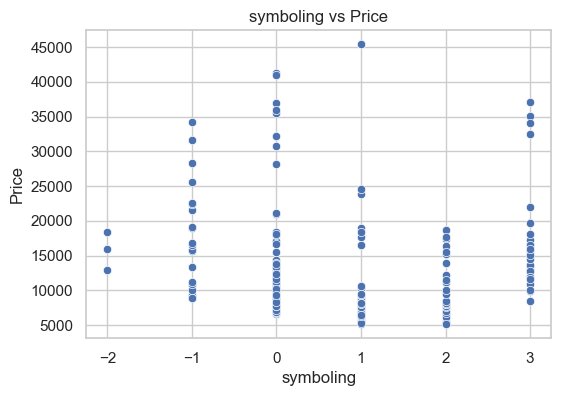

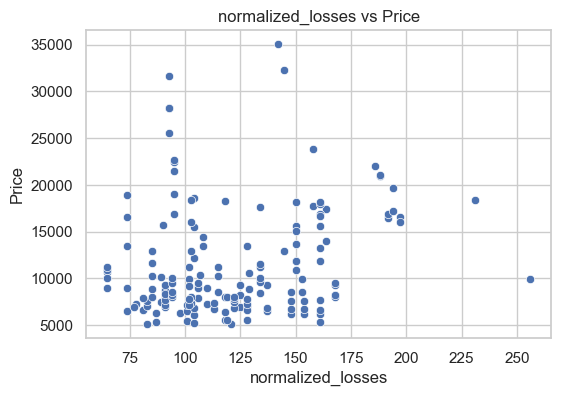

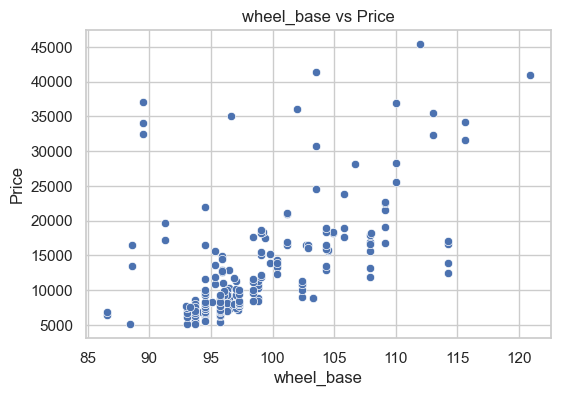

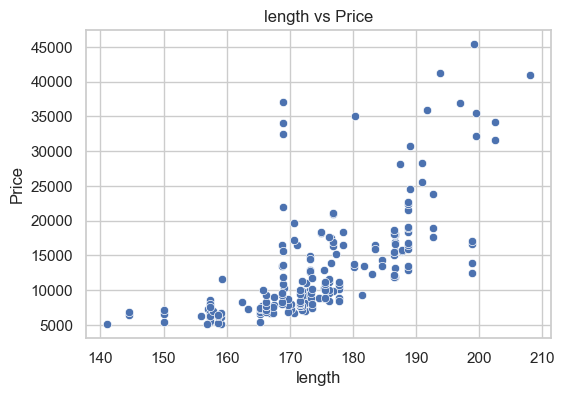

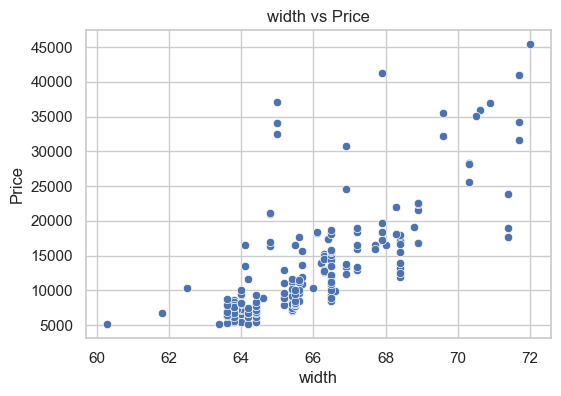

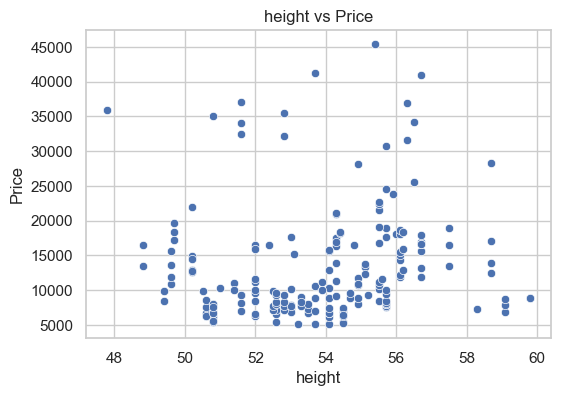

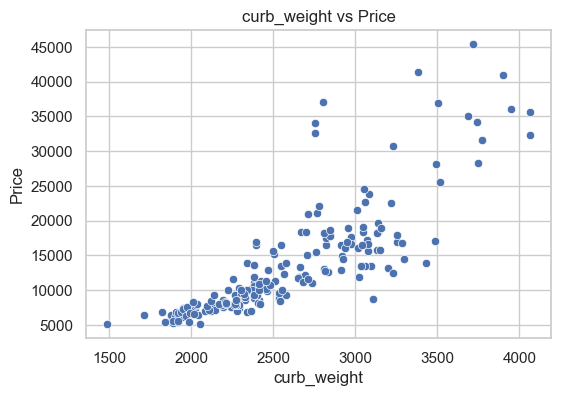

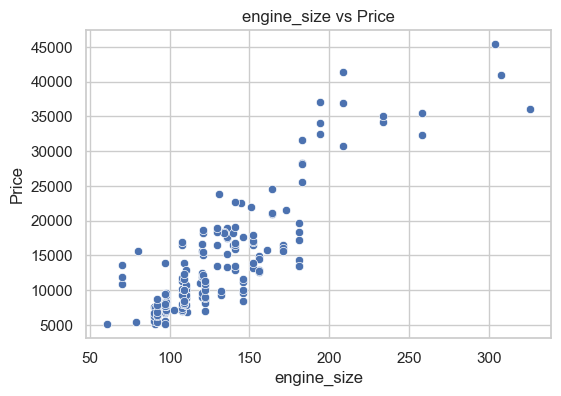

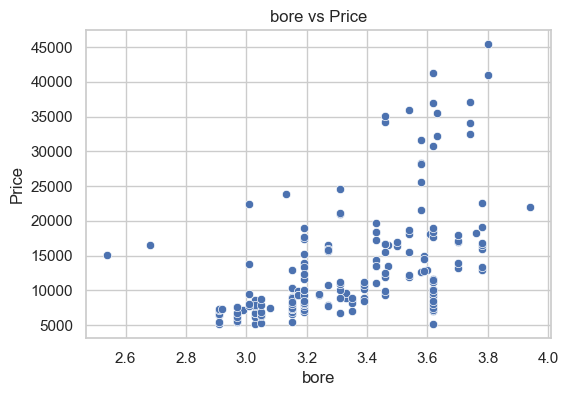

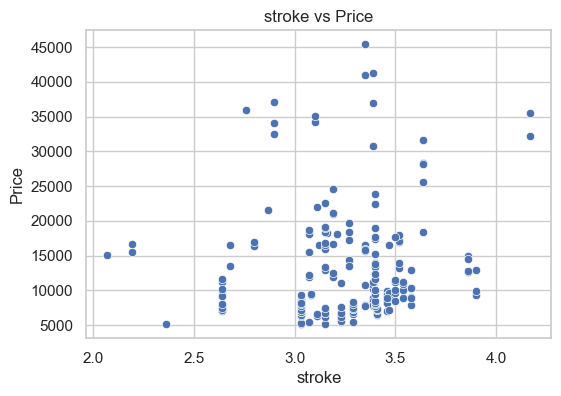

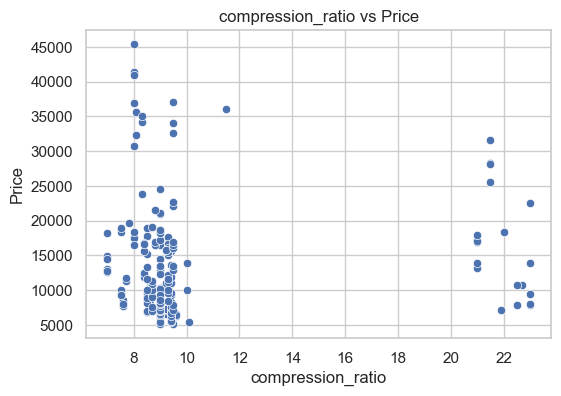

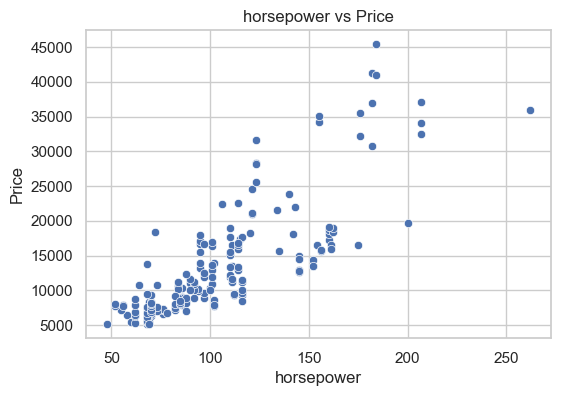

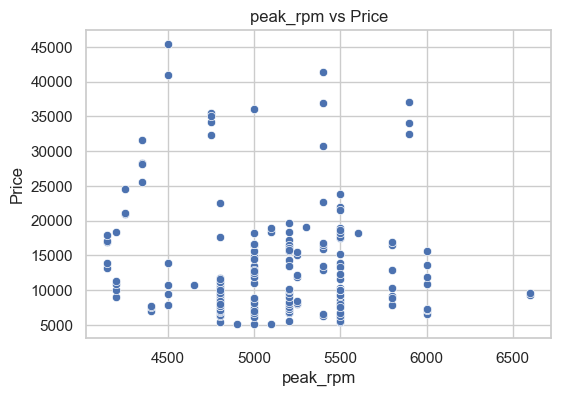

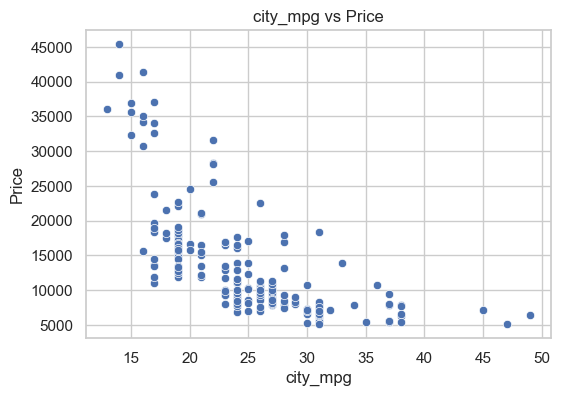

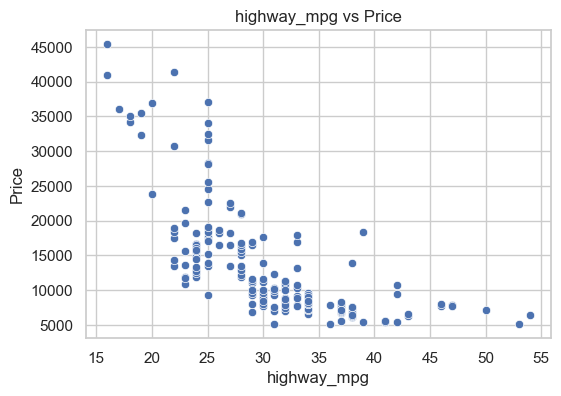

In [8]:
num_cols, cat_cols = get_column_types(df)
plot_num_vs_price(df, num_cols)

In [20]:
# Function to plot categorical vs price
def plot_cat_vs_price_top(df, cat_cols, top_n=10):
    
    for col in cat_cols:
        
        # Get top categories
        top_categories = df[col].value_counts().index[:top_n]
        
        filtered_df = df[df[col].isin(top_categories)]
        
        plt.figure(figsize=(7,4))
        
        sns.boxplot(x=filtered_df[col], y=filtered_df["price"])
        
        plt.title(f"{col} vs Price (Top {top_n})")
        plt.xlabel(col)
        plt.ylabel("Price")
        
        plt.xticks(rotation=90)
        
        plt.show()

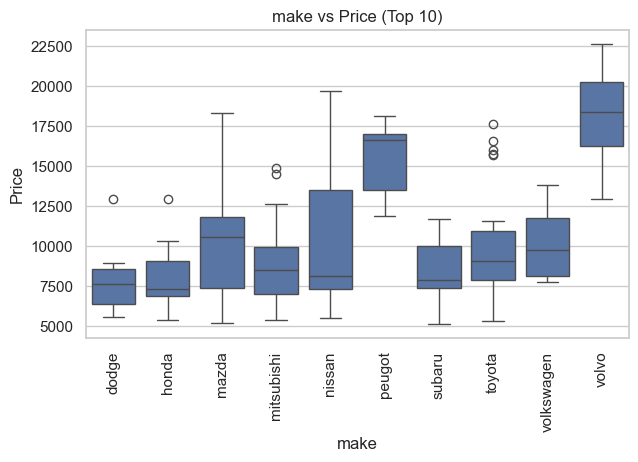

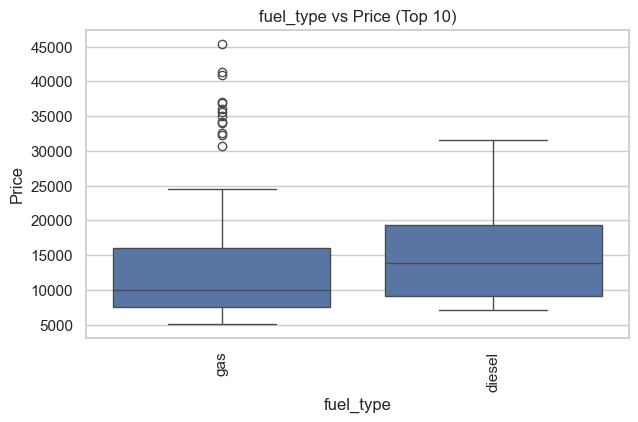

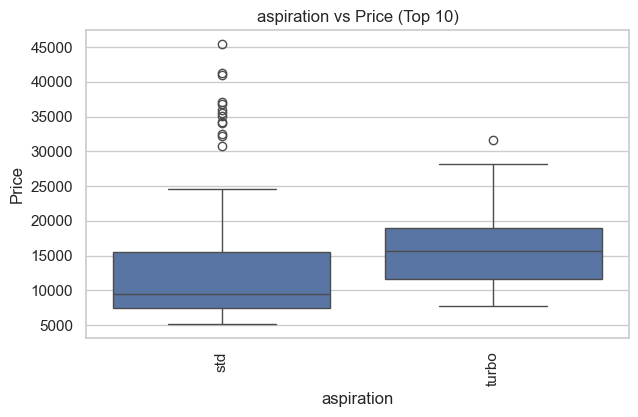

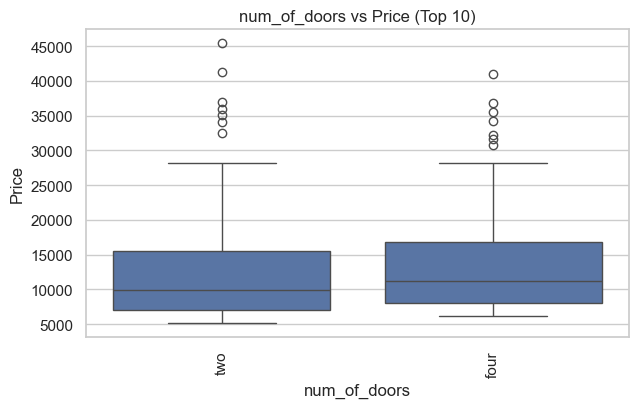

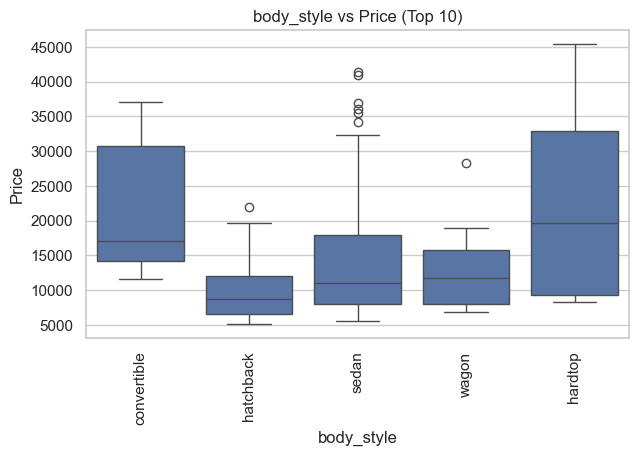

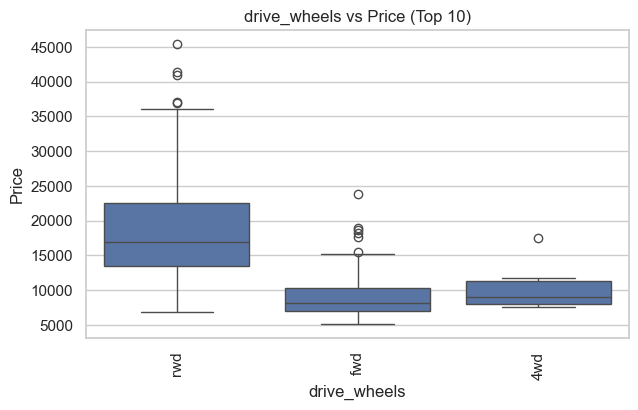

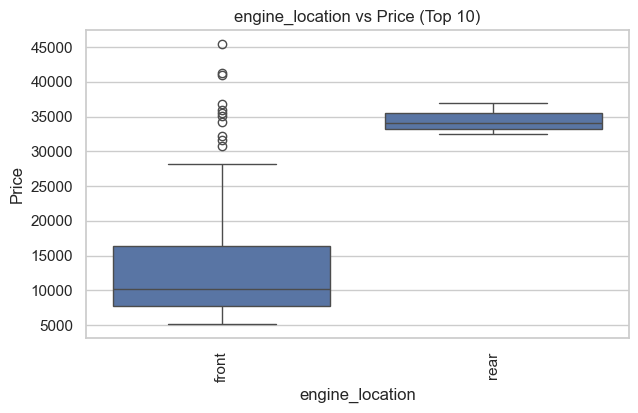

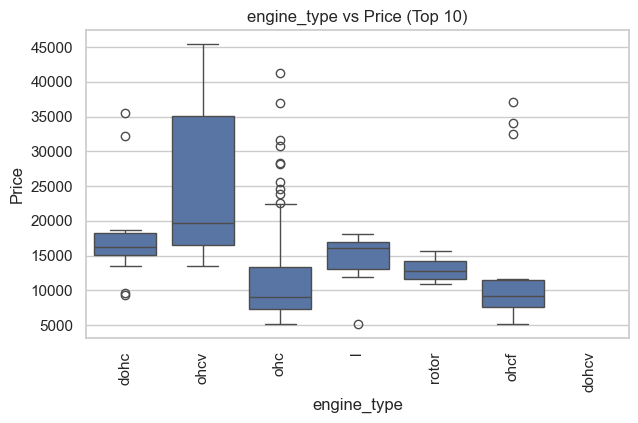

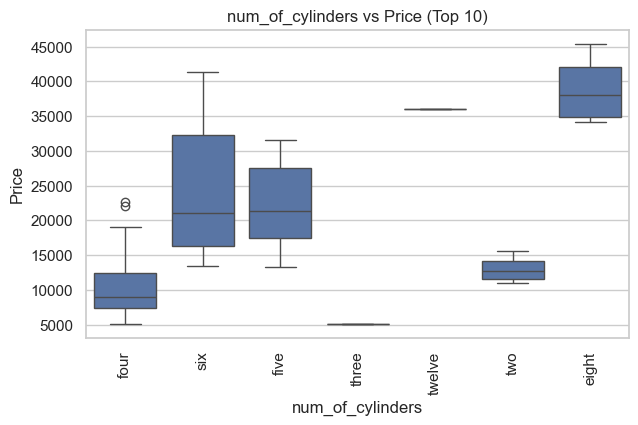

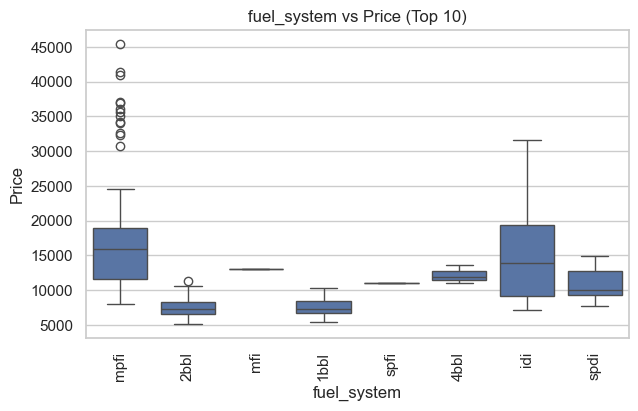

In [21]:
plot_cat_vs_price_top(df, cat_cols)

## Bivariate Analysis Summary

# Numerical Features vs Price
Engine_size shows a strong positive relationship with price, indicating that cars with larger engines are significantly more expensive.
Horsepower has a clear upward trend with price, meaning higher performance cars cost more.
Curb_weight is strongly positively correlated with price, showing that heavier vehicles tend to be more expensive.
Wheel_base, length, and width show moderate positive relationships with price, suggesting that larger cars are generally priced higher.
Height does not show any clear relationship with price, indicating it is not an important factor.
Stroke and compression_ratio display scattered patterns with no consistent trend, making them weak predictors of price.
Peak_rpm has no clear relationship with price and appears randomly distributed.
City_mpg and highway_mpg show a negative relationship with price, meaning fuel-efficient cars are generally cheaper.

# Categorical Features vs Price
Make: Significant variation exists across brands, with some brands consistently priced higher (premium) and others lower (economy), making it an important factor.
Fuel Type: Diesel cars tend to have slightly higher prices compared to gas cars, though gas cars show a wider price range.
Aspiration: Turbocharged cars have higher prices compared to standard ones, indicating performance impact on pricing.
Number of Doors: Very little difference in price distribution, suggesting it has minimal impact.
Body Style: Convertibles and hardtops are generally more expensive, while hatchbacks are cheaper, indicating clear market segmentation.
Drive Wheels: Rear-wheel drive cars tend to be more expensive, while front-wheel drive cars are cheaper.
Engine Location: Rear-engine cars are significantly more expensive, though they are very few in number.
Engine Type: Advanced engine types are associated with higher prices, while simpler ones fall in lower price ranges.
Number of Cylinders: Cars with more cylinders tend to have higher prices, showing a strong relationship with performance.
Fuel System: Advanced fuel systems like MPFI are associated with higher prices compared to simpler systems.

# Key Insights
Strong relationships exist between price and performance-related features such as engine_size, horsepower, and cylinders.
Physical size of the car (length, width, wheel_base) moderately influences price.
Fuel efficiency (mpg) is inversely related to price, indicating cheaper cars are more fuel-efficient.
Several categorical features like make, drive_wheels, and body_style clearly differentiate price segments.
Some features such as number of doors, height, and peak_rpm have little to no impact on price.
Presence of outliers in many relationships indicates existence of premium or luxury vehicles.

# Conclusion
Bivariate analysis reveals that car price is primarily influenced by performance, engine characteristics, and brand positioning, while basic structural features have minimal impact. These relationships are crucial for selecting important features for predictive modeling.